# Trabajo Final — Modelos Matemáticos para la Ciencia III (MMC-III)
## Campo de viento WINTEM — Nivel de vuelo F340 (34 000 ft) · Grupo 2


**Integrantes del Grupo 2:**
- Julca Delgado, Enrique 
- Alba Pérez, Diana Patricia 
- Delgado Pérez, José Alexis 

---

### Detalles del Reporte
- **Pronóstico válido:** 19 18:00 UTC (13:00 hora Perú).
- **Entorno:** Ejecutar con el kernel del venv local `Notebook/.venv` (Python 3.12).
- **Datos:** `../Data/F340_Data.csv`
- **Nota técnica:** Las flechas van de un solo color; la magnitud del viento se lee por el tamaño de la flecha y la referencia de 50 kt.

# 1. Introducción

El presente trabajo forma parte del curso de **Modelos Matemáticos para la Ciencia III (MMC-III)** y tiene como objetivo el análisis numérico y la visualización de variables atmosféricas críticas en el nivel de vuelo **F340** (aproximadamente 34,000 pies o 10.3 km de altitud).

### 1.1 Contexto Aeronáutico: El formato WINTEM
La información procesada en este informe proviene de los reportes **WINTEM** (*Winds and Temperatures at Altitude*), un producto meteorológico estandarizado utilizado en la aviación internacional. Estos reportes proporcionan datos esenciales sobre la dirección del viento, la velocidad (en nudos) y la temperatura (en grados Celsius) en distintos niveles de presión atmosférica.

El nivel **F340** es de especial interés meteorológico y operativo. Corresponde a la altitud de crucero habitual de las aeronaves comerciales y se encuentra cercano a la corriente en chorro (*jet stream*), donde los gradientes térmicos y de viento son significativos. Este nivel resulta óptimo para capturar la dinámica atmosférica de alta cizalladura, pues es precisamente allí donde los gradientes de vorticidad son más intensos y predecibles, facilitando el análisis de la estabilidad sinóptica y la identificación de estructuras dinámicas de gran escala.

El nivel **F340** es de especial interés meteorológico y operativo, ya que corresponde a la altitud de crucero habitual de las aeronaves comerciales y se encuentra cercano a la corriente en chorro (*jet stream*), donde los gradientes térmicos y de viento son significativos.

### 1.2 El Problema Científico
Los datos WINTEM presentan un desafío computacional: son **muestras discretas y dispersas** (datos no estructurados) sobre una región geográfica extensa. Para comprender la dinámica atmosférica, no basta con observar puntos aislados; es necesario reconstruir campos continuos que permitan aplicar operadores diferenciales. 

### 1.3 Objetivos
El objetivo principal de este proyecto es transformar las muestras crudas de WINTEM en campos vectoriales y escalares mediante técnicas de **interpolación espacial**. A partir de estos campos, se calcularán y analizarán los operadores de **divergencia** y **vorticidad**, los cuales son indicadores clave para:
* Identificar centros de alta y baja presión.
* Diagnosticar la inestabilidad atmosférica.
* Comprender la relación entre los gradientes de temperatura y la dinámica del viento (baroclinidad).

Este análisis permitirá al **Grupo 2** interpretar el comportamiento de la atmósfera en la región de estudio, aplicando herramientas de computación científica para la visualización y el diagnóstico meteorológico.


---

## 2. Configuración del entorno
En esta sección se inicializan las herramientas necesarias para la manipulación de datos, el procesamiento numérico y la generación de representaciones gráficas. Adicionalmente, se establecen los parámetros estéticos y de configuración del sistema para asegurar la consistencia y calidad visual en los resultados.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from pathlib import Path
from scipy.interpolate import griddata

# Silenciar advertencias molestas
warnings.filterwarnings("ignore", category=UserWarning, module="cartopy")

# Estilo académico
plt.rcParams.update({'font.family': 'serif', 'font.size': 12, 'figure.dpi': 150})

## 3. Carga y preprocesamiento de datos
En esta sección se realiza la importación del conjunto de datos crudos, seguida de la limpieza y transformación de las variables atmosféricas. Se convierten las coordenadas geográficas a un formato numérico adecuado y se derivan los componentes vectoriales del viento ($u, v$) a partir de la dirección y velocidad, estructurando la información para permitir los cálculos matemáticos posteriores.

In [71]:
# --- Cargar datos (notebook en Notebook/, CSV en ../Data/) ---
from pathlib import Path

csv_path = Path("../Data/F340_Data.csv")
if not csv_path.exists():
    csv_path = Path("Data/F340_Data.csv")  # por si se ejecuta desde la raiz del proyecto

df = pd.read_csv(csv_path)
df.head()

,Región,Día Emisión,Hora Emisión,Hora Pronóstico,Latitud,Longitud,Dirección (°),Velocidad (KT),Temperatura
0,FBNA27,19,03:29 UTC,18:00 UTC,450N,1300W,280,29,M43
1,FBNA27,19,03:29 UTC,18:00 UTC,450N,1250W,270,21,M44
2,FBNA27,19,03:29 UTC,18:00 UTC,450N,1200W,280,21,M44
3,FBNA27,19,03:29 UTC,18:00 UTC,450N,1150W,290,25,M44
4,FBNA27,19,03:29 UTC,18:00 UTC,450N,1100W,310,31,M45


In [72]:
# --- Coordenadas y variables ---
def to_lat(s):
    v = int(s[:3]) / 10
    return -v if s[3] == "S" else v

def to_lon(s):
    return -int(s[:4]) / 10          # todas son W -> negativo

df["lat"]  = df["Latitud"].apply(to_lat)
df["lon"]  = df["Longitud"].apply(to_lon)
df["dir"]  = df["Dirección (°)"].astype(int)
df["spd"]  = df["Velocidad (KT)"].astype(int)
df["temp"] = -df["Temperatura"].str[1:].astype(int)   # M43 -> -43 °C

In [73]:
# --- Componentes u, v  (dirección = DE DÓNDE viene el viento) ---
th = np.deg2rad(df["dir"].values)
df["u"] = -df["spd"] * np.sin(th)   # + hacia el Este
df["v"] = -df["spd"] * np.cos(th)   # + hacia el Norte

## 4. Discretización del dominio e interpolación de datos

Debido a que las observaciones meteorológicas provenientes de reportes WINTEM se encuentran dispersas irregularmente en el espacio geográfico, es imposible aplicar operadores diferenciales (como el gradiente o la divergencia) directamente sobre los datos crudos. Para resolver esto, realizamos un proceso en dos etapas: la discretización del dominio y la interpolación sobre malla regular.

### 4.1. Discretización mediante Malla Regular
El primer paso es definir una estructura matricial uniforme que sirva de base para los cálculos numéricos. Utilizamos un *meshgrid* (malla regular) de dimensiones $110 \times 110$ nodos. Matemáticamente, esto proyecta el espacio continuo en un conjunto de puntos $(x_i, y_j)$, donde las variables atmosféricas serán evaluadas mediante métodos de diferencias finitas en etapas posteriores. Esta malla actúa como el lienzo geométrico que regulariza la resolución espacial del campo.

### 4.2. Fundamentos de la Interpolación
Para estimar los valores en los nodos $(x_i, y_j)$ a partir de los datos de estaciones dispersas $S = \{ (x_k, y_k, z_k) \}_{k=1}^n$, empleamos dos métodos matemáticos interconectados:

#### A. Triangulación de Delaunay
El dominio es particionado mediante la **Triangulación de Delaunay** $DT(S)$. Esta técnica asegura que el círculo circunscrito de cualquier triángulo no contenga otros puntos en su interior. Esto maximiza el ángulo mínimo de los triángulos, evitando configuraciones espaciales degeneradas  y garantizando una estabilidad numérica superior para la interpolación.



#### B. Interpolación Lineal Baricéntrica
Una vez realizada la triangulación, para un punto $P$ dentro de un triángulo con vértices $V_1, V_2, V_3$, definimos su posición mediante **coordenadas baricéntricas** $(\lambda_1, \lambda_2, \lambda_3)$, que cumplen:
$$P = \lambda_1 V_1 + \lambda_2 V_2 + \lambda_3 V_3$$
sujeto a las restricciones:
$$\sum_{j=1}^{3} \lambda_j = 1, \quad \lambda_j \geq 0$$

El valor de la variable atmosférica $f(P)$ se calcula como la combinación lineal ponderada de los valores en los vértices:
$$f(P) = \lambda_1 f(V_1) + \lambda_2 f(V_2) + \lambda_3 f(V_3)$$



Este procedimiento garantiza una superficie continua, permitiéndonos transformar un conjunto de puntos aislados en campos vectoriales y escalares diferenciables, aptos para el análisis dinámico.

In [87]:
# 1. Preparar la malla regular (el lienzo 110x110)
grid_lon, grid_lat = np.meshgrid(
    np.linspace(df["lon"].min(), df["lon"].max(), 110), 
    np.linspace(df["lat"].min(), df["lat"].max(), 110)
)

# 2. Interpolación: Convertir los datos dispersos a matrices 2D
temp_grid = griddata((df["lon"], df["lat"]), df["temp"], (grid_lon, grid_lat), method='linear')
u_grid = griddata((df["lon"], df["lat"]), df["u"], (grid_lon, grid_lat), method='linear')
v_grid = griddata((df["lon"], df["lat"]), df["v"], (grid_lon, grid_lat), method='linear')

## 5. Visualización del estado termodinámico y cinemático
En esta etapa, procedemos a la representación gráfica de las variables atmosféricas reconstruidas. La visualización científica es fundamental para la interpretación cualitativa de patrones meteorológicos, permitiendo integrar en una misma proyección cartográfica la distribución térmica y el flujo del viento.

### 5.1 Representación de variables escalares
La temperatura se despliega mediante un mapa de contornos rellenos (`contourf`), el cual permite visualizar la magnitud del campo escalar. Complementariamente, se añaden isolíneas de isoterma (`contour`) para delimitar con mayor precisión las regiones con valores térmicos constantes, facilitando la identificación de gradientes y estructuras térmicas complejas.

### 5.2 Representación del campo vectorial
El campo de viento se representa mediante vectores (`quiver`), donde la dirección y longitud del vector indican el rumbo y magnitud de la velocidad en el nivel F340. Dado que nuestra malla de interpolación es densa (110x110), aplicamos un submuestreo  en el despliegue de los vectores. Esta reducción de densidad es una técnica estándar en computación gráfica para evitar la saturación visual y el solapamiento de elementos, garantizando que el patrón del flujo pueda ser interpretado claramente sin perder información física relevante.

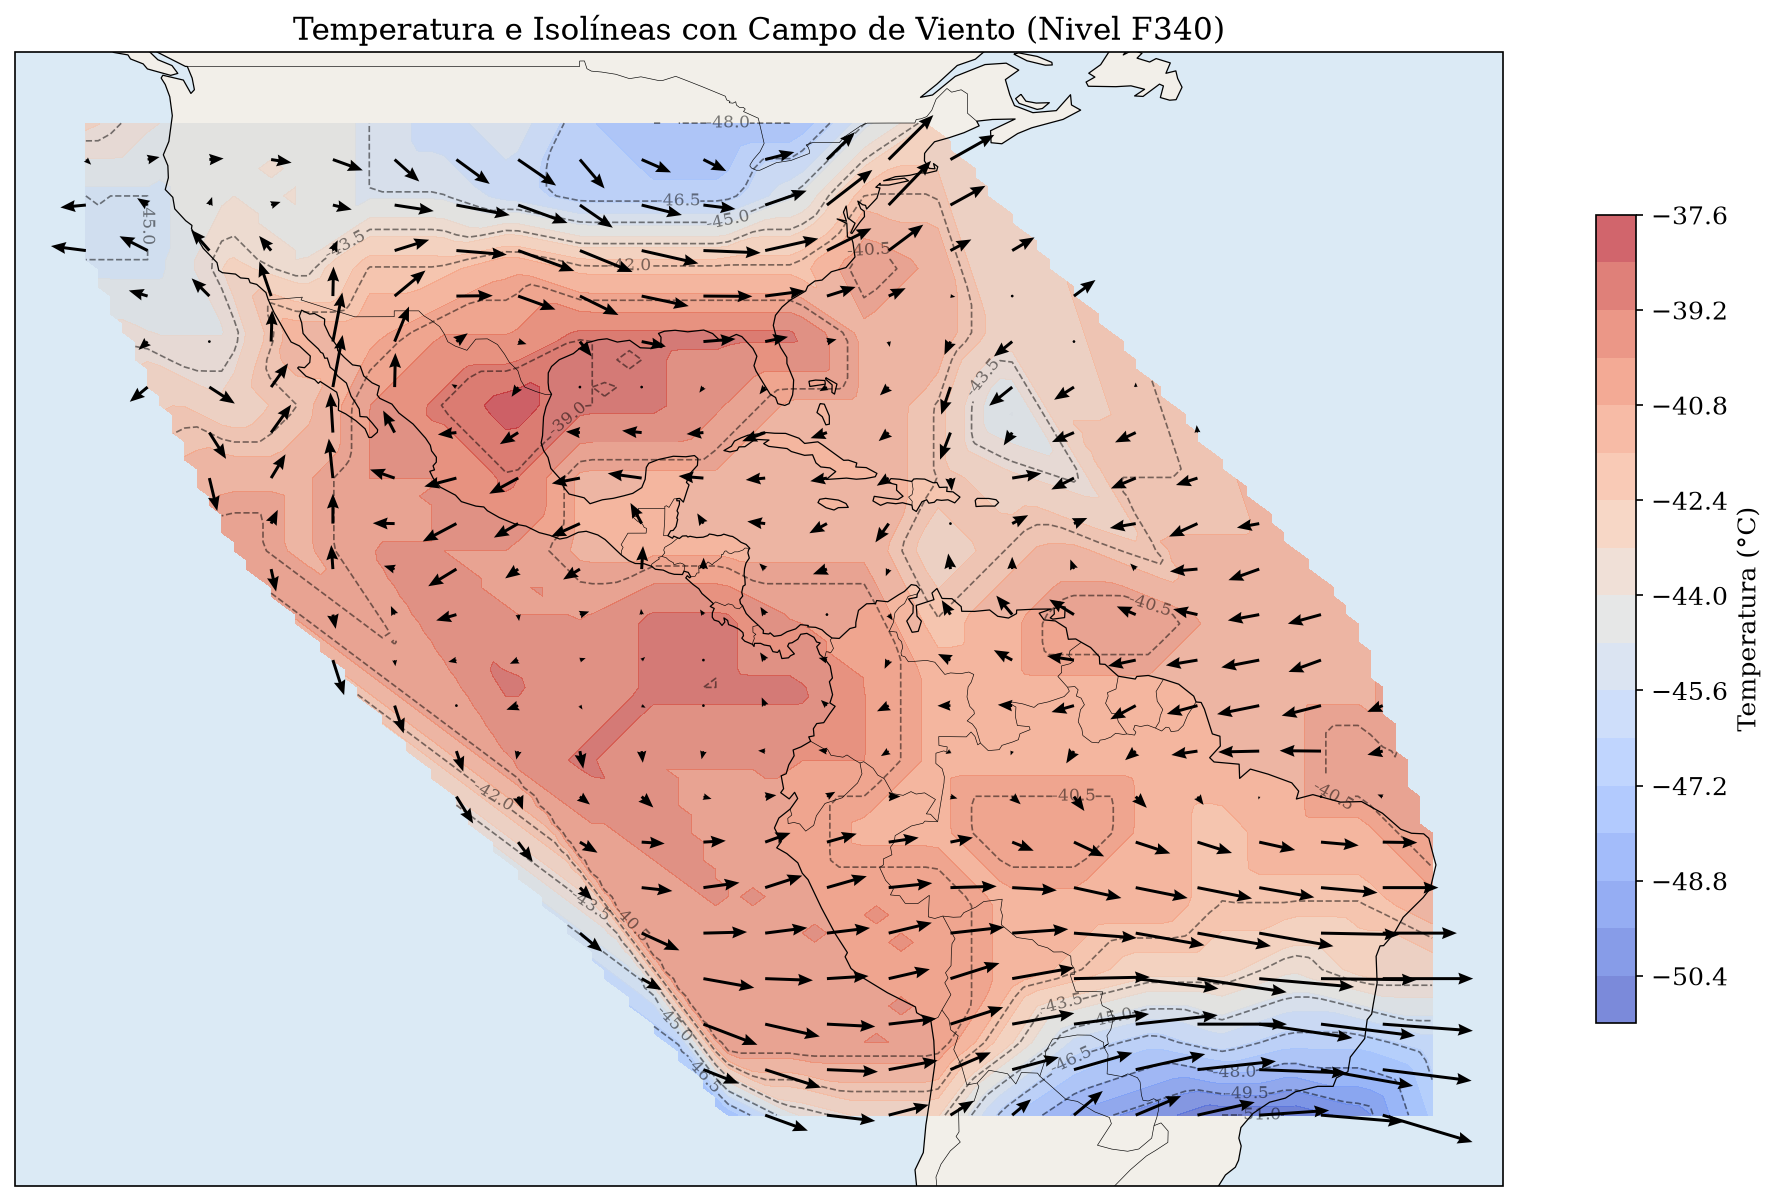

In [83]:
# 3. Graficación Profesional
fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-135, -30, -30, 50], crs=ccrs.PlateCarree())

# Capas base
ax.add_feature(cfeature.COASTLINE, lw=0.6)
ax.add_feature(cfeature.BORDERS, lw=0.3)
ax.add_feature(cfeature.LAND, facecolor="#f2efe9")
ax.add_feature(cfeature.OCEAN, facecolor="#dbeaf5")

# Mapa de calor de temperatura
cf = ax.contourf(grid_lon, grid_lat, temp_grid, 
                 levels=20, cmap="coolwarm", alpha=0.7, transform=ccrs.PlateCarree())

# Isolíneas
cs = ax.contour(grid_lon, grid_lat, temp_grid, 
                levels=10, colors='black', linewidths=0.8, alpha=0.5, transform=ccrs.PlateCarree())

# Etiquetado de las líneas ---
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')

# Quiver con subsampling (el truco del [::5, ::5])
step = 5 
q = ax.quiver(grid_lon[::step, ::step], grid_lat[::step, ::step], 
              u_grid[::step, ::step], v_grid[::step, ::step],
              color="black", scale=1200, width=0.002, headwidth=4,
              transform=ccrs.PlateCarree())

# Estética
plt.colorbar(cf, ax=ax, orientation="vertical", shrink=0.7, label='Temperatura (°C)')
ax.set_title("Temperatura e Isolíneas con Campo de Viento (Nivel F340)", fontsize=15)

plt.show()

## 6. Análisis de operadores diferenciales atmosféricos

Para diagnosticar la dinámica atmosférica a gran escala, es fundamental analizar las propiedades del campo de viento mediante operadores diferenciales. Estos nos permiten cuantificar el comportamiento del flujo de aire, separando los efectos de convergencia, divergencia y rotación.

### 6.1 Fundamentos matemáticos de los operadores
El cálculo de estos operadores se realiza mediante el método de diferencias finitas, aproximando las derivadas parciales del campo vectorial de viento $\vec{V} = (u, v)$ mediante el esquema de diferencias centrales:

1. **Divergencia ($\nabla \cdot \vec{V}$):** Mide la tasa de expansión o contracción del flujo. Se define como:
   $$\nabla \cdot \vec{V} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}$$
   Un valor positivo indica divergencia (salida de masa), mientras que un valor negativo indica convergencia (acumulación de masa).

2. **Vorticidad Relativa ($\zeta$):** Mide la rotación local del fluido respecto a un eje vertical. Se define como la componente vertical del rotacional:
   $$\zeta = \left( \nabla \times \vec{V} \right)_z = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}$$
   Valores positivos indican rotación ciclónica, mientras que los negativos indican rotación anticiclónica.

Utilizamos la función `np.gradient` para computar estas derivadas parciales sobre nuestra malla regular.

In [ ]:
def calcular_operadores_vectoriales(u, v, dx, dy):
    """
    Calcula la divergencia y vorticidad de un campo vectorial.
    """
    # np.gradient calcula la derivada parcial central
    dv_dy, dv_dx = np.gradient(v, dy, dx)
    du_dy, du_dx = np.gradient(u, dy, dx)
    
    # Cálculos
    divergencia = du_dx + dv_dy
    vorticidad = dv_dx - du_dy
    
    return divergencia, vorticidad

In [77]:
# llamamos a la funcion 
div, vort = calcular_operadores_vectoriales(u_grid, v_grid, dx=1, dy=1)



### 6.2 Campo de Divergencia
En esta visualización, las regiones en tonos rojos resaltan las zonas de divergencia horizontal (posibles áreas de subsidencia o descenso de aire), mientras que los tonos azules identifican zonas de convergencia, donde el aire tiende a acumularse y, frecuentemente, a ascender, favoreciendo la inestabilidad atmosférica.

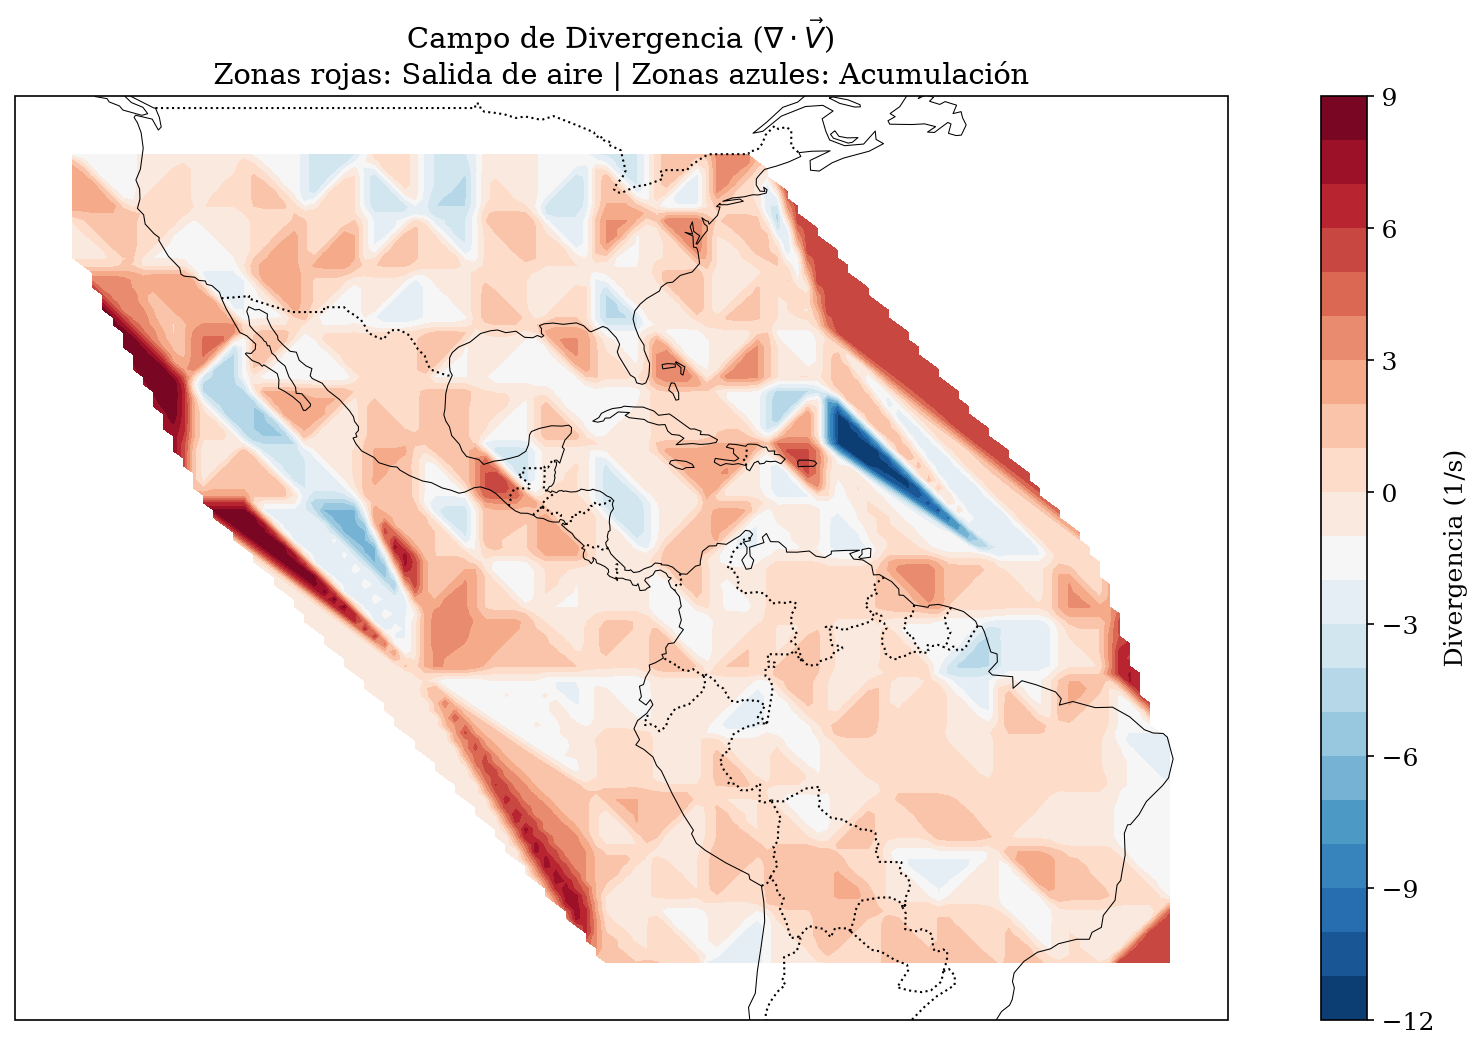

In [78]:
# --- Visualización de Divergencia ---
fig1 = plt.figure(figsize=(16, 8))
ax1 = plt.axes(projection=ccrs.PlateCarree())
ax1.set_extent([-135, -30, -30, 50], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE, lw=0.5)
ax1.add_feature(cfeature.BORDERS, linestyle=':')

# Usamos RdBu_r para que el rojo sea divergencia y el azul sea convergencia
cf_div = ax1.contourf(grid_lon, grid_lat, div, levels=20, cmap="RdBu_r", transform=ccrs.PlateCarree())
plt.colorbar(cf_div, ax=ax1, label='Divergencia (1/s)')

# Usamos 'r' para que las barras invertidas no den error
ax1.set_title(r"Campo de Divergencia ($\nabla \cdot \vec{V}$)" + "\n" + 
              "Zonas rojas: Salida de aire | Zonas azules: Acumulación", fontsize=14)
plt.show()


### 6.3 Campo de Vorticidad Relativa
La vorticidad nos permite localizar los centros de presión atmosférica. Los máximos de vorticidad (rojos) delimitan las áreas de actividad ciclónica (giro ciclónico), mientras que los mínimos (azules) corresponden a núcleos anticiclónicos, proporcionando una visión clara de la estructura sinóptica del flujo en el nivel F340.

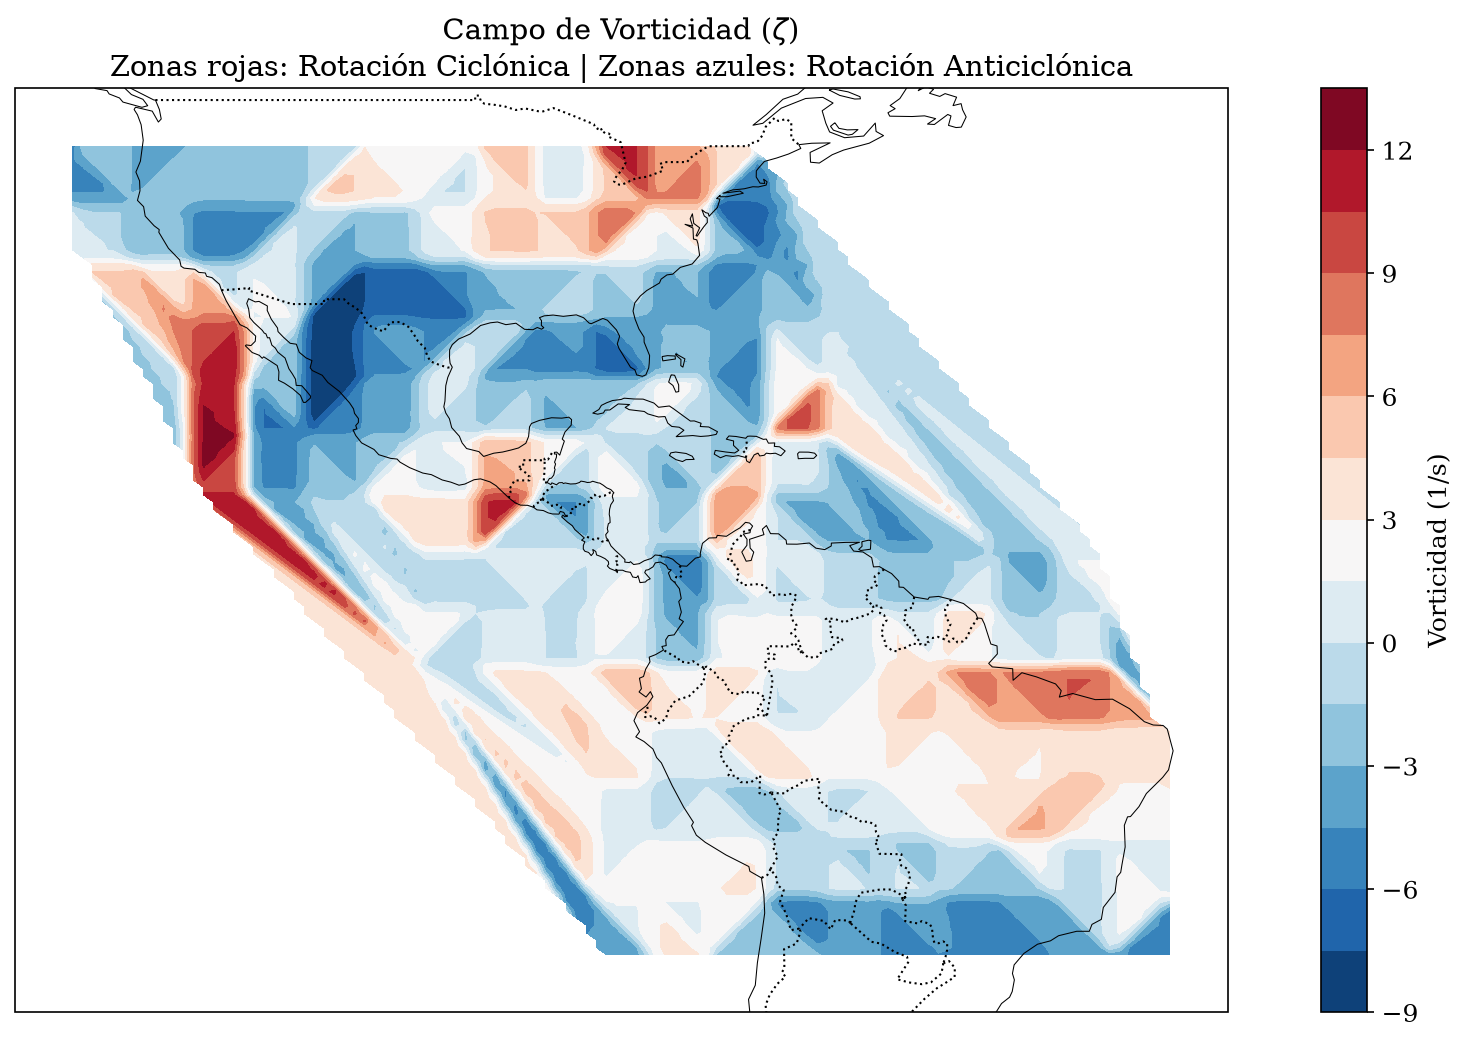

In [79]:
# --- Visualización de Vorticidad ---
fig2 = plt.figure(figsize=(16, 8))
ax2 = plt.axes(projection=ccrs.PlateCarree())
ax2.set_extent([-135, -30, -30, 50], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE, lw=0.5)
ax2.add_feature(cfeature.BORDERS, linestyle=':')

# Rojo: Vorticidad positiva (Ciclónica), Azul: Vorticidad negativa (Anticiclónica)
cf_vort = ax2.contourf(grid_lon, grid_lat, vort, levels=20, cmap="RdBu_r", transform=ccrs.PlateCarree())
plt.colorbar(cf_vort, ax=ax2, label='Vorticidad (1/s)')

# Usamos 'r' para evitar el SyntaxWarning con \zeta
ax2.set_title(r"Campo de Vorticidad ($\zeta$)" + "\n" + 
              "Zonas rojas: Rotación Ciclónica | Zonas azules: Rotación Anticiclónica", fontsize=14)
plt.show()

### 6.4 Síntesis: Análisis térmico-dinámico integrado
Finalmente, integramos la información térmica con la dinámica del flujo mediante una visualización dual. Superponemos los contornos de vorticidad sobre el campo de temperatura para examinar la baroclinidad: la relación entre los gradientes térmicos y la vorticidad nos permite identificar zonas de intensificación de sistemas meteorológicos, un aspecto crítico en la predicción del clima en el nivel F340.

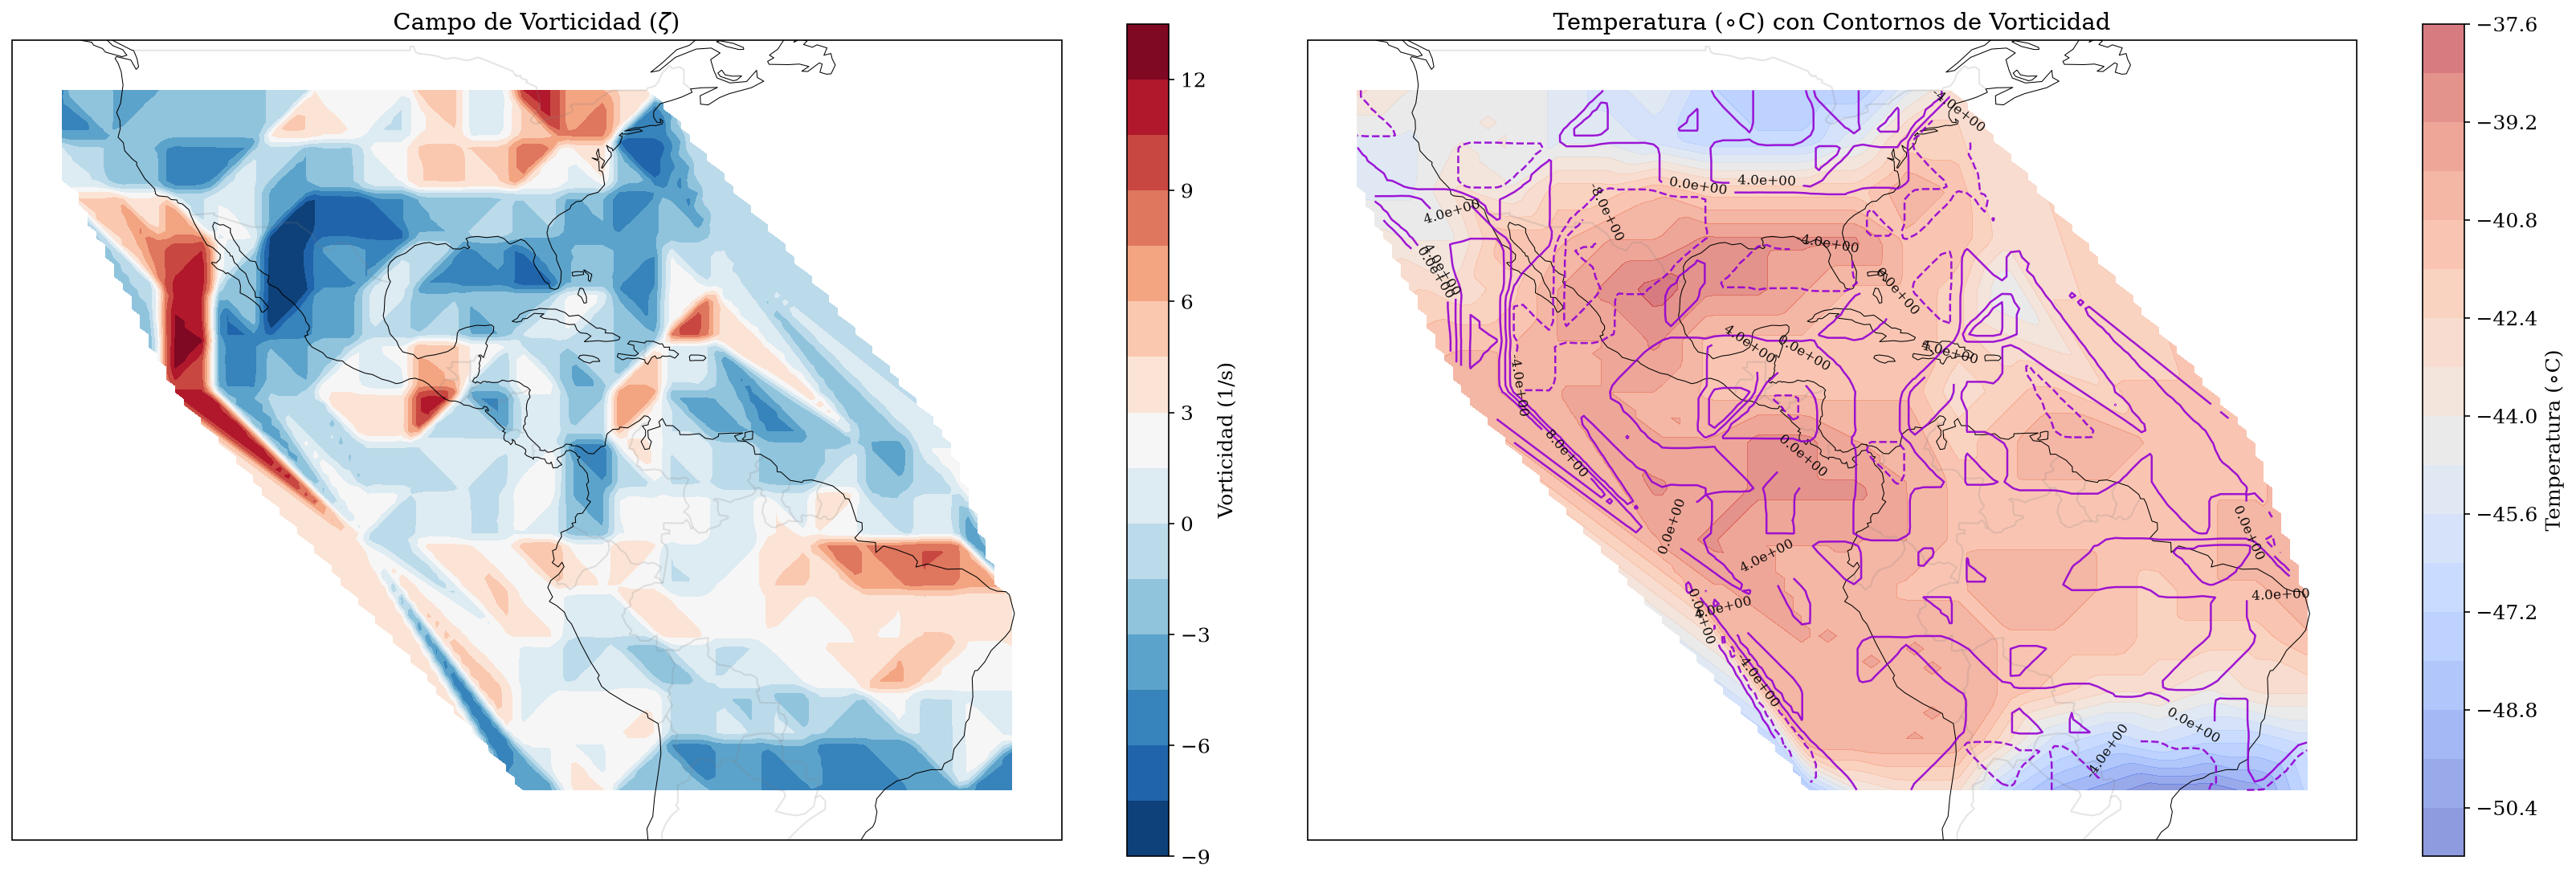

In [80]:
# --- ESTO ELIMINA EL ---
warnings.filterwarnings("ignore", category=UserWarning, module="cartopy")

# 1. Crear el lienzo de 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(22, 9), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Definimos parámetros visuales
cmap_temp = "coolwarm"
cmap_vort = "RdBu_r"

# --- IZQUIERDA: Mapa de Vorticidad ---
ax0 = axes[0]
ax0.set_extent([-135, -30, -30, 50], crs=ccrs.PlateCarree())
ax0.add_feature(cfeature.COASTLINE, lw=0.5, color='black')
ax0.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.2, color='gray', facecolor='none')

cf0 = ax0.contourf(grid_lon, grid_lat, vort, levels=20, cmap=cmap_vort, transform=ccrs.PlateCarree())
plt.colorbar(cf0, ax=ax0, label=r'Vorticidad (1/s)', shrink=0.8)
ax0.set_title(r"Campo de Vorticidad ($\zeta$)")

# --- DERECHA: Temperatura con Contornos de Vorticidad ---
ax1 = axes[1]
ax1.set_extent([-135, -30, -30, 50], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE, lw=0.5, color='black')
ax1.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.2, color='gray', facecolor='none')

# Fondo de temperatura
cf1 = ax1.contourf(grid_lon, grid_lat, temp_grid, levels=20, cmap=cmap_temp, alpha=0.6, transform=ccrs.PlateCarree())

# Superposición de contornos de vorticidad
cs1 = ax1.contour(grid_lon, grid_lat, vort, levels=6, colors='darkviolet', 
                  linewidths=1.2, alpha=0.9, transform=ccrs.PlateCarree())

# Etiquetado limpio con notación científica
ax1.clabel(cs1, inline=True, fontsize=8, fmt='%.1e', colors='black') 

ax1.set_title(r"Temperatura ($\circ$C) con Contornos de Vorticidad")
plt.colorbar(cf1, ax=ax1, label=r'Temperatura ($\circ$C)', shrink=0.8)

plt.tight_layout()
plt.show()